<a href="https://colab.research.google.com/github/jadlm3407/AgenticFlow/blob/main/Prediccion_mundiales_eliminatorias_3_(claude).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# INTERRUPTOR PRINCIPAL, INFORMADO POR EL BACKTEST (MEJORA 7)
# ==========================================================
# False = usar directamente el GLM de Poisson + Dixon-Coles (más simple, y el que
#         ganó el backtest real contra el Mundial 2026).
# True  = usar la capa de XGBoost encima (más features, pero no demostró ganar en
#         el backtest — actívalo solo si quieres seguir experimentando).
USAR_XGBOOST = False


In [ ]:
# ==========================================================
# CELDA 1: IMPORTACIÓN DE DATOS
# ==========================================================
import os

if not os.path.exists('international_results'):
    os.system('git clone https://github.com/martj42/international_results.git')

import pandas as pd
import numpy as np
from scipy.stats import poisson
from scipy.optimize import minimize_scalar
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

results     = pd.read_csv('international_results/results.csv')
shootouts   = pd.read_csv('international_results/shootouts.csv')
goalscorers = pd.read_csv('international_results/goalscorers.csv')

print(f"Resultados cargados:    {results.shape[0]:>6} partidos | {results.shape[1]} columnas")
print(f"Tandas de penaltis:     {shootouts.shape[0]:>6} registros")
print(f"Goleadores registrados: {goalscorers.shape[0]:>6} goles")


Resultados cargados:     49505 partidos | 9 columnas
Tandas de penaltis:        682 registros
Goleadores registrados:  47886 goles


In [ ]:
# ==========================================================
# CELDA 2: CONFIGURACIÓN Y LIMPIEZA
# ==========================================================

# ---- PARÁMETROS DEL CRUCE A PREDECIR ----
equipo_1 = "Argentina"
equipo_2 = "Switzerland"

ANIO_MINIMO              = 2018
PARTIDO_EN_CAMPO_NEUTRAL = True
PESO_TORNEO_PARTIDO      = 5.0   # 5 = Mundial

# ---- Ponderación temporal (MEJORA 3) ----
# Un partido pesa menos cuanto más viejo es, además de por el tipo de torneo.
# MEDIA_VIDA_ANIOS = tras cuántos años el peso de un partido se reduce a la mitad.
# Usamos una vida media larga porque, a diferencia del fútbol de clubes (partidos
# cada semana), una selección solo juega ~10-15 partidos al año.
MEDIA_VIDA_ANIOS = 2.5
XI_DECAY = np.log(2) / (MEDIA_VIDA_ANIOS * 365)

# ---- Validación cruzada para eliminar la fuga de datos (MEJORA 1) ----
N_FOLDS_LEAKAGE = 5

# ---- Parámetros de prórroga ----
# FACTOR_PRORROGA se recalcula empíricamente más abajo (MEJORA 4); este es solo
# el valor de respaldo por si la muestra de partidos con tanda de penales es
# demasiado pequeña para estimarlo con confianza.
FACTOR_PRORROGA_RESPALDO = 0.30

# ---- Simulación Monte Carlo con incertidumbre paramétrica (MEJORA 5) ----
N_SIMULACIONES = 100_000
N_BOOTSTRAP    = 300          # nº de "mundos posibles" para la fuerza de los equipos
MAX_GOLES_SIM  = 10           # rango de goles considerado en la distribución conjunta

# ---- Conversión de fechas ----
results['date']      = pd.to_datetime(results['date'])
goalscorers['date']  = pd.to_datetime(goalscorers['date'])
shootouts['date']    = pd.to_datetime(shootouts['date'])
results['id_resultado'] = results.index   # id global, antes de filtrar (para unir el Elo histórico)

# ---- Filtrado temporal ----
df = results[results['date'].dt.year >= ANIO_MINIMO].copy()
gs = goalscorers[goalscorers['date'].dt.year >= ANIO_MINIMO].copy()
so = shootouts[shootouts['date'].dt.year >= ANIO_MINIMO].copy()

# ---- Limpieza ----
columnas_clave = ['home_team', 'away_team', 'home_score', 'away_score']
df = df.dropna(subset=columnas_clave).reset_index(drop=True)
df['home_score'] = df['home_score'].astype(int)
df['away_score'] = df['away_score'].astype(int)
df['neutral']    = df['neutral'].astype(bool)
df['partido_id'] = df.index          # id único de partido, se usa para el fold OOF
gs = gs.dropna(subset=['scorer'])

# ---- Peso por importancia del torneo ----
def peso_torneo_fn(nombre_torneo):
    t = nombre_torneo.lower()
    if 'world cup' in t and 'qualification' not in t:
        return 5.0
    if 'world cup' in t and 'qualification' in t:
        return 3.0
    continentales = ['euro', 'copa américa', 'copa america', 'cup of nations', 'asian cup', 'gold cup']
    if any(c in t for c in continentales) and 'qualification' not in t:
        return 4.0
    if any(c in t for c in continentales) and 'qualification' in t:
        return 2.5
    if 'nations league' in t:
        return 3.0
    if t == 'friendly':
        return 1.0
    return 1.5

df['peso_torneo'] = df['tournament'].apply(peso_torneo_fn)

# ---- Peso temporal: decae exponencialmente con la antigüedad (MEJORA 3) ----
fecha_referencia = df['date'].max()
df['dias_transcurridos'] = (fecha_referencia - df['date']).dt.days
df['peso_tiempo'] = np.exp(-XI_DECAY * df['dias_transcurridos'])
df['peso_total']  = df['peso_torneo'] * df['peso_tiempo']

# ---- Comprobación de equipos ----
equipos_disponibles = set(df['home_team']).union(set(df['away_team']))
for equipo in [equipo_1, equipo_2]:
    if equipo not in equipos_disponibles:
        print(f"⚠️  Aviso: '{equipo}' no aparece en el histórico filtrado. Revisa el nombre exacto.")

print(f"\n✅ Configurado: {equipo_1} vs {equipo_2} | Datos desde {ANIO_MINIMO} | N_simulaciones={N_SIMULACIONES:,}")
print(f"   Vida media del peso temporal: {MEDIA_VIDA_ANIOS} años (ξ={XI_DECAY:.6f}/día)")

# ==========================================================
# CELDA 2.5: ELO HISTÓRICO (MEJORA 6 — señal complementaria al GLM)
# ==========================================================
# El GLM de Poisson separa ataque/defensa pero solo ve partidos desde ANIO_MINIMO.
# El Elo resume la fuerza GLOBAL de un equipo y se alimenta de TODO el historial
# disponible (desde 1872 en este dataset), lo cual ayuda sobre todo a selecciones
# con poco historial reciente (Cabo Verde, Curazao...). Replicamos aquí la
# metodología estándar de "World Football Elo Ratings" (eloratings.net):
#   K = 60 fase final de Mundial | 50 fase final continental/intercontinental grande
#   K = 40 clasificatorias de Mundial/continentales y Nations League | 30 el resto | 20 amistosos
#   + multiplicador por diferencia de goles, y +100 puntos de "local" en campo no neutral.
ELO_INICIAL  = 1500.0
ELO_HOME_ADV = 100.0


def peso_elo_k(nombre_torneo):
    t = nombre_torneo.lower()
    if 'world cup' in t and 'qualification' not in t:
        return 60.0
    finales_grandes = ['euro', 'copa américa', 'copa america', 'cup of nations',
                        'asian cup', 'gold cup', 'confederations cup']
    if any(c in t for c in finales_grandes) and 'qualification' not in t:
        return 50.0
    if 'qualification' in t or 'nations league' in t:
        return 40.0
    if t == 'friendly':
        return 20.0
    return 30.0


def factor_diferencia_goles_elo(dif_goles):
    if dif_goles <= 1:
        return 1.0
    elif dif_goles == 2:
        return 1.5
    else:
        return (11 + dif_goles) / 8.0


def calcular_elo_historico(resultados_completos):
    """Procesa TODO el histórico en orden cronológico y devuelve:
       - resultados_completos con elo_pre_home/elo_pre_away (Elo justo ANTES de cada partido)
       - elo_actual: dict {equipo: Elo más reciente}, para predecir partidos futuros."""
    r = resultados_completos.dropna(subset=['home_score', 'away_score']).sort_values('date').copy()
    elo_actual_local = {}
    elo_pre_home = np.empty(len(r))
    elo_pre_away = np.empty(len(r))

    for pos, fila in enumerate(r.itertuples()):
        r_h = elo_actual_local.get(fila.home_team, ELO_INICIAL)
        r_a = elo_actual_local.get(fila.away_team, ELO_INICIAL)
        elo_pre_home[pos] = r_h
        elo_pre_away[pos] = r_a

        ventaja = 0.0 if fila.neutral else ELO_HOME_ADV
        dr = (r_h + ventaja) - r_a
        we_h = 1.0 / (10 ** (-dr / 400.0) + 1.0)

        if fila.home_score > fila.away_score:
            w_h = 1.0
        elif fila.home_score < fila.away_score:
            w_h = 0.0
        else:
            w_h = 0.5

        k = peso_elo_k(fila.tournament)
        g = factor_diferencia_goles_elo(abs(fila.home_score - fila.away_score))
        delta = k * g * (w_h - we_h)

        elo_actual_local[fila.home_team] = r_h + delta
        elo_actual_local[fila.away_team] = r_a - delta

    r['elo_pre_home'] = elo_pre_home
    r['elo_pre_away'] = elo_pre_away
    return r, elo_actual_local


resultados_con_elo, elo_actual = calcular_elo_historico(results)

# Incorporar el Elo pre-partido al dataset filtrado (df), emparejando por id_resultado
df = df.merge(
    resultados_con_elo[['id_resultado', 'elo_pre_home', 'elo_pre_away']],
    on='id_resultado', how='left'
)
df['elo_pre_home'] = df['elo_pre_home'].fillna(ELO_INICIAL)
df['elo_pre_away'] = df['elo_pre_away'].fillna(ELO_INICIAL)


def elo_de(equipo):
    return elo_actual.get(equipo, ELO_INICIAL)


dr_real   = (elo_de(equipo_1) + (0 if PARTIDO_EN_CAMPO_NEUTRAL else ELO_HOME_ADV)) - elo_de(equipo_2)
we_elo_1  = 1.0 / (10 ** (-dr_real / 400.0) + 1.0)
print(f"\n✅ Elo histórico calculado sobre {len(resultados_con_elo):,} partidos (desde {resultados_con_elo['date'].min().year}).")
print(f"   Elo actual {equipo_1}: {elo_de(equipo_1):.0f}   |   Elo actual {equipo_2}: {elo_de(equipo_2):.0f}")
print(f"   Expectativa Elo pura (solo referencia, no es 1X2): {equipo_1} {we_elo_1:.1%}  vs  {equipo_2} {1 - we_elo_1:.1%}")



✅ Configurado: Argentina vs Switzerland | Datos desde 2018 | N_simulaciones=100,000
   Vida media del peso temporal: 2.5 años (ξ=0.000760/día)

✅ Elo histórico calculado sobre 49,501 partidos (desde 1872).
   Elo actual Argentina: 2233   |   Elo actual Switzerland: 2023
   Expectativa Elo pura (solo referencia, no es 1X2): Argentina 77.1%  vs  Switzerland 22.9%


In [ ]:
# ==========================================================
# CELDA 3: MODELO DE POISSON (BASE) + CORRECCIÓN DIXON-COLES
# ==========================================================

local = df[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'neutral',
            'peso_torneo', 'peso_total', 'partido_id', 'elo_pre_home', 'elo_pre_away']].rename(
    columns={'home_team': 'team', 'away_team': 'opponent', 'home_score': 'goles', 'away_score': 'goles_contra',
             'elo_pre_home': 'elo_team', 'elo_pre_away': 'elo_opponent'}
)
local['es_local'] = 1

visitante = df[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'neutral',
                'peso_torneo', 'peso_total', 'partido_id', 'elo_pre_home', 'elo_pre_away']].rename(
    columns={'away_team': 'team', 'home_team': 'opponent', 'away_score': 'goles', 'home_score': 'goles_contra',
             'elo_pre_home': 'elo_opponent', 'elo_pre_away': 'elo_team'}
)
visitante['es_local'] = 0

datos_poisson = pd.concat([local, visitante], ignore_index=True)
datos_poisson['ventaja_local'] = datos_poisson['es_local'] * (~datos_poisson['neutral']).astype(int)
datos_poisson['elo_diff'] = datos_poisson['elo_team'] - datos_poisson['elo_opponent']
datos_poisson = datos_poisson.sort_values(['team', 'date']).reset_index(drop=True)


def ajustar_poisson(data_subset):
    """Ajusta el GLM de Poisson (fuerza ofensiva/defensiva por equipo) sobre el subconjunto dado."""
    return smf.glm(
        formula="goles ~ ventaja_local + team + opponent",
        data=data_subset,
        family=sm.families.Poisson(),
        var_weights=data_subset['peso_total']
    ).fit(method='lbfgs', maxiter=300, disp=False)


# ---- Modelo final, con TODO el histórico: es el que se usa para predecir el
#      cruce real (ahí no hay fuga, es un partido genuinamente futuro) ----
modelo_poisson_full = ajustar_poisson(datos_poisson)


def fuerza_ofensiva(equipo, modelo=modelo_poisson_full):
    return modelo.params.get(f"team[T.{equipo}]", 0.0)


def vulnerabilidad_defensiva(equipo, modelo=modelo_poisson_full):
    return modelo.params.get(f"opponent[T.{equipo}]", 0.0)


def error_estandar_ataque(equipo, modelo=modelo_poisson_full):
    return modelo.bse.get(f"team[T.{equipo}]", modelo.bse.median())


def error_estandar_defensa(equipo, modelo=modelo_poisson_full):
    return modelo.bse.get(f"opponent[T.{equipo}]", modelo.bse.median())


# ---- Amortiguación de la incertidumbre paramétrica ----
# El SE "crudo" de un coeficiente individual del GLM (team/opponent) sobreestima la
# incertidumbre de la predicción FINAL, porque (a) hay que usar la covarianza entre
# el coeficiente de ataque y el de defensa (dos equipos distintos, pero el modelo de
# efectos fijos two-way los correlaciona) y (b) la capa de XGBoost + la mezcla con
# cara-a-cara ya regularizan/moderan esos coeficientes crudos antes de llegar al xG
# final. Una propagación perfecta requeriría re-entrenar todo el pipeline (GLM+XGBoost)
# en cada iteración bootstrap, lo cual es demasiado costoso para uso interactivo.
# Este factor es una simplificación explícita, no una propagación exacta.
FACTOR_AMORTIGUACION_INCERTIDUMBRE = 0.5


def varianza_diferencia_log_xg(equipo_atacante, equipo_defensor, modelo=modelo_poisson_full):
    """Var(β_ataque[atacante] + β_defensa[defensor]), usando la covarianza real del
    GLM (no solo la suma ingenua de varianzas, que sobreestima el error)."""
    cov = modelo.cov_params()
    na = f"team[T.{equipo_atacante}]"
    nd = f"opponent[T.{equipo_defensor}]"
    var_a = cov.loc[na, na] if na in cov.index else modelo.bse.median() ** 2
    var_d = cov.loc[nd, nd] if nd in cov.index else modelo.bse.median() ** 2
    cov_ad = cov.loc[na, nd] if (na in cov.index and nd in cov.index) else 0.0
    return max(var_a + var_d + 2 * cov_ad, 1e-6)


print(f"\nFuerza ofensiva   {equipo_1}: {fuerza_ofensiva(equipo_1):+.3f}  (SE={error_estandar_ataque(equipo_1):.3f})")
print(f"Vulnerabilidad defensiva {equipo_1}: {vulnerabilidad_defensiva(equipo_1):+.3f}  (SE={error_estandar_defensa(equipo_1):.3f})")
print(f"Fuerza ofensiva   {equipo_2}: {fuerza_ofensiva(equipo_2):+.3f}  (SE={error_estandar_ataque(equipo_2):.3f})")
print(f"Vulnerabilidad defensiva {equipo_2}: {vulnerabilidad_defensiva(equipo_2):+.3f}  (SE={error_estandar_defensa(equipo_2):.3f})")

# ----------------------------------------------------------
# MEJORA 1: efectos fijos "out-of-fold" para entrenar XGBoost sin fuga
# ----------------------------------------------------------
# Repartimos los PARTIDOS (no las filas) en N_FOLDS_LEAKAGE folds, así la fila
# "local" y la fila "visitante" de un mismo partido siempre caen en el mismo fold.
kf = KFold(n_splits=N_FOLDS_LEAKAGE, shuffle=True, random_state=42)
partidos_unicos = df['partido_id'].values
fold_de_partido = np.empty(len(partidos_unicos), dtype=int)
for fold_num, (_, idx_test) in enumerate(kf.split(partidos_unicos)):
    fold_de_partido[idx_test] = fold_num
mapa_fold = dict(zip(partidos_unicos, fold_de_partido))
datos_poisson['fold'] = datos_poisson['partido_id'].map(mapa_fold)

datos_poisson['ataque_team_oof'] = 0.0
datos_poisson['defensa_opp_oof'] = 0.0

for k in range(N_FOLDS_LEAKAGE):
    train_k = datos_poisson[datos_poisson['fold'] != k]
    modelo_k = ajustar_poisson(train_k)
    mask_k = datos_poisson['fold'] == k
    datos_poisson.loc[mask_k, 'ataque_team_oof'] = datos_poisson.loc[mask_k, 'team'].apply(
        lambda e, m=modelo_k: m.params.get(f"team[T.{e}]", 0.0))
    datos_poisson.loc[mask_k, 'defensa_opp_oof'] = datos_poisson.loc[mask_k, 'opponent'].apply(
        lambda e, m=modelo_k: m.params.get(f"opponent[T.{e}]", 0.0))

print(f"\n✅ Efectos fijos out-of-fold calculados ({N_FOLDS_LEAKAGE} folds) para eliminar la fuga de datos.")

# ----------------------------------------------------------
# MEJORA 2: Dixon-Coles real — corrección τ para marcadores bajos
# ----------------------------------------------------------
def tau_dixon_coles(x, y, lam, mu, rho):
    """Factor de corrección de Dixon-Coles para (0,0),(0,1),(1,0),(1,1)."""
    x = np.asarray(x)
    y = np.asarray(y)
    tau = np.ones(np.broadcast(x, y).shape, dtype=float)
    tau = np.where((x == 0) & (y == 0), 1 - lam * mu * rho, tau)
    tau = np.where((x == 0) & (y == 1), 1 + lam * rho, tau)
    tau = np.where((x == 1) & (y == 0), 1 + mu * rho, tau)
    tau = np.where((x == 1) & (y == 1), 1 - rho, tau)
    return tau


def matriz_conjunta_dc(lam, mu, rho, max_goles):
    """Matriz de probabilidad conjunta P(goles_1=i, goles_2=j) con corrección Dixon-Coles, normalizada."""
    i = np.arange(max_goles + 1)
    j = np.arange(max_goles + 1)
    I, J = np.meshgrid(i, j, indexing='ij')
    base = np.outer(poisson.pmf(i, lam), poisson.pmf(j, mu))
    tau = tau_dixon_coles(I, J, lam, mu, rho)
    matriz = np.clip(base * tau, 0, None)
    return matriz / matriz.sum()


# Estimación de rho por máxima verosimilitud sobre el histórico real ----
pred_local = pd.DataFrame({
    'team': df['home_team'], 'opponent': df['away_team'],
    'ventaja_local': (~df['neutral']).astype(int)
})
pred_visit = pd.DataFrame({
    'team': df['away_team'], 'opponent': df['home_team'],
    'ventaja_local': 0
})
lambda_hist = modelo_poisson_full.predict(pred_local).values
mu_hist     = modelo_poisson_full.predict(pred_visit).values
x_hist      = df['home_score'].values
y_hist      = df['away_score'].values


def neg_log_lik_rho(rho, x, y, lam, mu):
    tau = tau_dixon_coles(x, y, lam, mu, rho)
    tau = np.clip(tau, 1e-6, None)
    return -np.sum(np.log(tau))


resultado_rho = minimize_scalar(
    neg_log_lik_rho, bounds=(-0.3, 0.3), method='bounded',
    args=(x_hist, y_hist, lambda_hist, mu_hist)
)
rho_hat = resultado_rho.x
print(f"\n✅ Parámetro de correlación Dixon-Coles estimado sobre {len(df)} partidos: ρ = {rho_hat:+.4f}")
print(f"   (ρ<0 es lo típico: leve exceso de 0-0/1-0/0-1/1-1 frente a Poisson independiente)")



Fuerza ofensiva   Argentina: +2.314  (SE=0.739)
Vulnerabilidad defensiva Argentina: -1.549  (SE=0.912)
Fuerza ofensiva   Switzerland: +2.092  (SE=0.739)
Vulnerabilidad defensiva Switzerland: -1.244  (SE=0.909)

✅ Efectos fijos out-of-fold calculados (5 folds) para eliminar la fuga de datos.

✅ Parámetro de correlación Dixon-Coles estimado sobre 8204 partidos: ρ = -0.0413
   (ρ<0 es lo típico: leve exceso de 0-0/1-0/0-1/1-1 frente a Poisson independiente)


In [ ]:
# ==========================================================
# CELDA 4: FEATURE ENGINEERING
# ==========================================================

N_FORMA = 5
datos_poisson['forma_gf'] = datos_poisson.groupby('team')['goles'].transform(
    lambda serie: serie.shift(1).rolling(N_FORMA, min_periods=1).mean()
)
datos_poisson['forma_gc'] = datos_poisson.groupby('team')['goles_contra'].transform(
    lambda serie: serie.shift(1).rolling(N_FORMA, min_periods=1).mean()
)
media_gf_global = datos_poisson['goles'].mean()
media_gc_global = datos_poisson['goles_contra'].mean()
datos_poisson['forma_gf'] = datos_poisson['forma_gf'].fillna(media_gf_global)
datos_poisson['forma_gc'] = datos_poisson['forma_gc'].fillna(media_gc_global)

def forma_actual(equipo):
    sub = datos_poisson[datos_poisson['team'] == equipo].sort_values('date').tail(N_FORMA)
    if sub.empty:
        return media_gf_global, media_gc_global
    return sub['goles'].mean(), sub['goles_contra'].mean()

# ---- Cara a cara ----
mask_h2h = (
    ((df['home_team'] == equipo_1) & (df['away_team'] == equipo_2)) |
    ((df['home_team'] == equipo_2) & (df['away_team'] == equipo_1))
)
h2h = df[mask_h2h]
n_h2h = len(h2h)

if n_h2h > 0:
    goles_h2h_1 = np.where(h2h['home_team'] == equipo_1, h2h['home_score'], h2h['away_score']).mean()
    goles_h2h_2 = np.where(h2h['home_team'] == equipo_2, h2h['home_score'], h2h['away_score']).mean()
else:
    goles_h2h_1, goles_h2h_2 = None, None

K_SHRINKAGE = 5
peso_h2h = n_h2h / (n_h2h + K_SHRINKAGE)

# ---- Diversidad y penaltis ----
# (ver limitación conocida en el docstring: esto sigue siendo un promedio histórico
#  completo, no "as-of-date"; queda como posible mejora futura)
diversidad          = gs.groupby(['team', 'date'])['scorer'].nunique().reset_index(name='goleadores_partido')
diversidad_equipo   = diversidad.groupby('team')['goleadores_partido'].mean()
pct_penalti_equipo  = gs.groupby('team')['penalty'].mean()
media_diversidad_global    = diversidad_equipo.mean()
media_pct_penalti_global   = pct_penalti_equipo.mean()

def goleadores_distintos(equipo):
    return diversidad_equipo.get(equipo, media_diversidad_global)

def pct_goles_penalti(equipo):
    return pct_penalti_equipo.get(equipo, media_pct_penalti_global)

# ---- Modelo de penales (Bayesian smoothing) ----
N_PRIOR_PENALES = 10   # "partidos virtuales" que anclan el prior al 50%

def shootout_winrate_bayesian(equipo):
    partidas = so[(so['home_team'] == equipo) | (so['away_team'] == equipo)]
    victorias = (partidas['winner'] == equipo).sum()
    n_tandas   = len(partidas)
    alpha = N_PRIOR_PENALES / 2
    beta  = N_PRIOR_PENALES / 2
    return (victorias + alpha) / (n_tandas + alpha + beta)

n_so_1 = len(so[(so['home_team'] == equipo_1) | (so['away_team'] == equipo_1)])
n_so_2 = len(so[(so['home_team'] == equipo_2) | (so['away_team'] == equipo_2)])
victorias_so_1 = ((so[(so['home_team'] == equipo_1) | (so['away_team'] == equipo_1)])['winner'] == equipo_1).sum()
victorias_so_2 = ((so[(so['home_team'] == equipo_2) | (so['away_team'] == equipo_2)])['winner'] == equipo_2).sum()
wr_1   = shootout_winrate_bayesian(equipo_1)
wr_2   = shootout_winrate_bayesian(equipo_2)

print(f"\nRécord en tandas de penaltis (con smoothing bayesiano):")
print(f"  {equipo_1}: {wr_1:.1%}  (sobre {n_so_1} tandas reales)")
print(f"  {equipo_2}: {wr_2:.1%}  (sobre {n_so_2} tandas reales)")

# ---- Volcar features al dataset (versión OOF para entrenar) ----
datos_poisson['goleadores_distintos'] = datos_poisson['team'].apply(goleadores_distintos)
datos_poisson['pct_goles_penalti']    = datos_poisson['team'].apply(pct_goles_penalti)

print(f"\nCara a cara desde {ANIO_MINIMO}: {n_h2h} partido(s)")
if n_h2h > 0:
    print(f"  Media de goles → {equipo_1}: {goles_h2h_1:.2f}  |  {equipo_2}: {goles_h2h_2:.2f}")

# ----------------------------------------------------------
# MEJORA 4: factor de prórroga empírico
# ----------------------------------------------------------
# Partidos que sabemos con certeza llegaron a los 120' porque aparecen en shootouts.csv
partidos_con_penales = so[['date', 'home_team', 'away_team']].drop_duplicates()
gs_et = gs.merge(partidos_con_penales, on=['date', 'home_team', 'away_team'], how='inner')
gs_et = gs_et.dropna(subset=['minute'])

MIN_PARTIDOS_PARA_FACTOR_EMPIRICO = 15
if len(partidos_con_penales) >= MIN_PARTIDOS_PARA_FACTOR_EMPIRICO and len(gs_et) > 0:
    goles_90  = int((gs_et['minute'] <= 90).sum())
    goles_et  = int((gs_et['minute'] > 90).sum())
    n_pen_muestra = len(partidos_con_penales)
    FACTOR_PRORROGA = goles_et / goles_90 if goles_90 > 0 else FACTOR_PRORROGA_RESPALDO
    origen_factor = f"empírico, sobre {n_pen_muestra} partidos con tanda de penales ({goles_90} goles en 90', {goles_et} en prórroga)"
else:
    FACTOR_PRORROGA = FACTOR_PRORROGA_RESPALDO
    origen_factor = f"de respaldo (muestra insuficiente: solo {len(partidos_con_penales)} partidos con penales desde {ANIO_MINIMO})"

print(f"\n✅ Factor de prórroga usado: {FACTOR_PRORROGA:.3f}  [{origen_factor}]")



Récord en tandas de penaltis (con smoothing bayesiano):
  Argentina: 64.3%  (sobre 4 tandas reales)
  Switzerland: 46.7%  (sobre 5 tandas reales)

Cara a cara desde 2018: 0 partido(s)

✅ Factor de prórroga usado: 0.088  [empírico, sobre 168 partidos con tanda de penales (136 goles en 90', 12 en prórroga)]


In [ ]:
# ==========================================================
# CELDA 5: XGBOOST + SIMULACIÓN MONTE CARLO PARA ELIMINATORIAS
# ==========================================================

# ----------------------------------------------------------
# A) ENTRENAMIENTO XGBOOST (con features out-of-fold, sin fuga) — opcional
# ----------------------------------------------------------
caracteristicas = [
    'ataque_team_oof', 'defensa_opp_oof',
    'ventaja_local',
    'forma_gf', 'forma_gc',
    'peso_torneo',
    'goleadores_distintos',
    'pct_goles_penalti',
    'elo_diff'
]

if USAR_XGBOOST:
    X = datos_poisson[caracteristicas]
    y = datos_poisson['goles']
    pesos_muestra = datos_poisson['peso_total']

    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X, y, pesos_muestra, test_size=0.2, random_state=42
    )

    modelo_xgb = XGBRegressor(
        objective='count:poisson',
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
    modelo_xgb.fit(X_train, y_train, sample_weight=w_train)

    mae = mean_absolute_error(y_test, modelo_xgb.predict(X_test))
    print(f"\nMAE XGBoost en test (con features OOF, sin fuga): {mae:.3f} goles/partido")
else:
    print(f"\n⚙️  USAR_XGBOOST=False: se usa directamente Poisson+Elo (ver MEJORA 7 / backtest).")

# ----------------------------------------------------------
# B) xG PARA EL PARTIDO
# ----------------------------------------------------------
gf1, gc1 = forma_actual(equipo_1)
gf2, gc2 = forma_actual(equipo_2)
ventaja_local_1 = 0 if PARTIDO_EN_CAMPO_NEUTRAL else 1
ventaja_local_2 = 0

def construir_fila(equipo, rival, ventaja_local, gf, gc):
    # NOTA: aquí usamos fuerza_ofensiva/vulnerabilidad_defensiva del modelo COMPLETO
    # (no OOF) porque este sí es un partido genuinamente futuro: no hay fuga.
    return pd.DataFrame([{
        'ataque_team_oof': fuerza_ofensiva(equipo),
        'defensa_opp_oof': vulnerabilidad_defensiva(rival),
        'ventaja_local': ventaja_local,
        'forma_gf': gf, 'forma_gc': gc,
        'peso_torneo': PESO_TORNEO_PARTIDO,
        'goleadores_distintos': goleadores_distintos(equipo),
        'pct_goles_penalti': pct_goles_penalti(equipo),
        'elo_diff': elo_de(equipo) - elo_de(rival)
    }])

if USAR_XGBOOST:
    xg1 = max(modelo_xgb.predict(construir_fila(equipo_1, equipo_2, ventaja_local_1, gf1, gc1))[0], 0.05)
    xg2 = max(modelo_xgb.predict(construir_fila(equipo_2, equipo_1, ventaja_local_2, gf2, gc2))[0], 0.05)
else:
    # Directamente del GLM de Poisson (sin la capa de XGBoost): esto fue lo que
    # ganó el backtest real contra el Mundial 2026 (ver docstring, mejora 7).
    vl1_glm = 0 if PARTIDO_EN_CAMPO_NEUTRAL else 1
    xg1 = modelo_poisson_full.predict(pd.DataFrame([{
        'team': equipo_1, 'opponent': equipo_2, 'ventaja_local': vl1_glm}]))[0]
    xg2 = modelo_poisson_full.predict(pd.DataFrame([{
        'team': equipo_2, 'opponent': equipo_1, 'ventaja_local': 0}]))[0]
    xg1, xg2 = max(xg1, 0.05), max(xg2, 0.05)

# Mezcla bayesiana con H2H
if n_h2h > 0:
    xg1 = (1 - peso_h2h) * xg1 + peso_h2h * goles_h2h_1
    xg2 = (1 - peso_h2h) * xg2 + peso_h2h * goles_h2h_2

xg1 = max(xg1, 0.05)
xg2 = max(xg2, 0.05)

xg1_prorroga = xg1 * FACTOR_PRORROGA
xg2_prorroga = xg2 * FACTOR_PRORROGA

print(f"\nxG estimado a 90 minutos:")
print(f"  {equipo_1}: {xg1:.3f}")
print(f"  {equipo_2}: {xg2:.3f}")
print(f"xG estimado en prórroga (30 min, factor={FACTOR_PRORROGA:.3f}):")
print(f"  {equipo_1}: {xg1_prorroga:.3f}")
print(f"  {equipo_2}: {xg2_prorroga:.3f}")

# ----------------------------------------------------------
# C) PROBABILIDAD DE GANAR PENALES (estimación puntual, para el resumen impreso)
# ----------------------------------------------------------
p1_gana_penales = wr_1 / (wr_1 + wr_2)
p2_gana_penales = 1 - p1_gana_penales

print(f"\nProbabilidad de ganar en penales (condicional a llegar a la tanda):")
print(f"  {equipo_1}: {p1_gana_penales:.1%}")
print(f"  {equipo_2}: {p2_gana_penales:.1%}")

# ----------------------------------------------------------
# D) SIMULACIÓN MONTE CARLO CON 3 FASES + 2 NIVELES DE INCERTIDUMBRE (MEJORA 5)
# ----------------------------------------------------------
#   Nivel externo ("bootstrap", N_BOOTSTRAP mundos posibles):
#     - re-muestrea la fuerza de cada equipo según su error estándar real
#     - re-muestrea el winrate de penales según su posterior Beta real
#   Nivel interno (dentro de cada mundo posible):
#     - 90 minutos: se muestrea directamente de la distribución conjunta con
#       corrección Dixon-Coles (MEJORA 2), no de dos Poisson independientes.
#     - prórroga: Poisson independiente con el factor empírico (MEJORA 4).
#     - penales: Bernoulli con el winrate muestreado de ese "mundo".
np.random.seed(42)

inner_n = N_SIMULACIONES // N_BOOTSTRAP
N_SIMULACIONES = inner_n * N_BOOTSTRAP  # ajuste por si no es divisible exacto

gana_e1_90  = np.zeros(N_SIMULACIONES, dtype=bool)
gana_e2_90  = np.zeros(N_SIMULACIONES, dtype=bool)
empate_90   = np.zeros(N_SIMULACIONES, dtype=bool)
gana_e1_et  = np.zeros(N_SIMULACIONES, dtype=bool)
gana_e2_et  = np.zeros(N_SIMULACIONES, dtype=bool)
empate_et   = np.zeros(N_SIMULACIONES, dtype=bool)
gana_e1_pen = np.zeros(N_SIMULACIONES, dtype=bool)
gana_e2_pen = np.zeros(N_SIMULACIONES, dtype=bool)

avanza_e1_por_bootstrap = np.zeros(N_BOOTSTRAP)

se_log_xg1 = FACTOR_AMORTIGUACION_INCERTIDUMBRE * np.sqrt(varianza_diferencia_log_xg(equipo_1, equipo_2))
se_log_xg2 = FACTOR_AMORTIGUACION_INCERTIDUMBRE * np.sqrt(varianza_diferencia_log_xg(equipo_2, equipo_1))

alpha_prior = N_PRIOR_PENALES / 2
beta_prior  = N_PRIOR_PENALES / 2

idx_inicio = 0
for b in range(N_BOOTSTRAP):
    idx_fin = idx_inicio + inner_n

    # ---- muestreo de incertidumbre paramétrica ----
    # Se resta sigma^2/2 antes de exponenciar para que E[xg_b] = xg (si no, una
    # perturbación log-normal sin corregir infla la media por la desigualdad de Jensen).
    ruido1 = np.random.normal(0, se_log_xg1)
    ruido2 = np.random.normal(0, se_log_xg2)
    xg1_b = max(xg1 * np.exp(ruido1 - 0.5 * se_log_xg1 ** 2), 0.05)
    xg2_b = max(xg2 * np.exp(ruido2 - 0.5 * se_log_xg2 ** 2), 0.05)

    wr1_b = np.random.beta(alpha_prior + victorias_so_1, beta_prior + n_so_1 - victorias_so_1)
    wr2_b = np.random.beta(alpha_prior + victorias_so_2, beta_prior + n_so_2 - victorias_so_2)
    p1_pen_b = wr1_b / (wr1_b + wr2_b)

    # ---- Fase 1: 90 minutos, muestreo directo de la conjunta Dixon-Coles ----
    matriz_b = matriz_conjunta_dc(xg1_b, xg2_b, rho_hat, MAX_GOLES_SIM)
    idx_muestra = np.random.choice(matriz_b.size, size=inner_n, p=matriz_b.flatten())
    g1_b = idx_muestra // (MAX_GOLES_SIM + 1)
    g2_b = idx_muestra % (MAX_GOLES_SIM + 1)

    e1_90_b  = g1_b > g2_b
    e2_90_b  = g2_b > g1_b
    emp_90_b = g1_b == g2_b

    # ---- Fase 2: prórroga ----
    xg1_et_b = xg1_b * FACTOR_PRORROGA
    xg2_et_b = xg2_b * FACTOR_PRORROGA
    g1_extra = np.random.poisson(xg1_et_b, size=inner_n)
    g2_extra = np.random.poisson(xg2_et_b, size=inner_n)
    g1_et_b = g1_b + np.where(emp_90_b, g1_extra, 0)
    g2_et_b = g2_b + np.where(emp_90_b, g2_extra, 0)

    e1_et_b  = emp_90_b & (g1_et_b > g2_et_b)
    e2_et_b  = emp_90_b & (g2_et_b > g1_et_b)
    emp_et_b = emp_90_b & (g1_et_b == g2_et_b)

    # ---- Fase 3: penales ----
    e1_pen_b = emp_et_b & (np.random.random(inner_n) < p1_pen_b)
    e2_pen_b = emp_et_b & ~e1_pen_b

    gana_e1_90[idx_inicio:idx_fin]  = e1_90_b
    gana_e2_90[idx_inicio:idx_fin]  = e2_90_b
    empate_90[idx_inicio:idx_fin]   = emp_90_b
    gana_e1_et[idx_inicio:idx_fin]  = e1_et_b
    gana_e2_et[idx_inicio:idx_fin]  = e2_et_b
    empate_et[idx_inicio:idx_fin]   = emp_et_b
    gana_e1_pen[idx_inicio:idx_fin] = e1_pen_b
    gana_e2_pen[idx_inicio:idx_fin] = e2_pen_b

    avanza_e1_por_bootstrap[b] = (e1_90_b | e1_et_b | e1_pen_b).mean()

    idx_inicio = idx_fin

# ---- Consolidar resultados ----
e1_gana_normal   = gana_e1_90
e1_gana_prorroga = gana_e1_et
e1_gana_penales  = gana_e1_pen
e2_gana_normal   = gana_e2_90
e2_gana_prorroga = gana_e2_et
e2_gana_penales  = gana_e2_pen

prob_e1_normal   = np.mean(e1_gana_normal)
prob_e1_prorroga = np.mean(e1_gana_prorroga)
prob_e1_penales  = np.mean(e1_gana_penales)

prob_e2_normal   = np.mean(e2_gana_normal)
prob_e2_prorroga = np.mean(e2_gana_prorroga)
prob_e2_penales  = np.mean(e2_gana_penales)

prob_avanza_e1   = prob_e1_normal + prob_e1_prorroga + prob_e1_penales
prob_avanza_e2   = prob_e2_normal + prob_e2_prorroga + prob_e2_penales

prob_prorroga    = np.mean(empate_90)
prob_llegan_pen  = np.mean(empate_et)

# ---- Intervalo de incertidumbre paramétrica (MEJORA 5) ----
ci_e1_5, ci_e1_95 = np.percentile(avanza_e1_por_bootstrap, [5, 95])
ci_e2_5, ci_e2_95 = 1 - ci_e1_95, 1 - ci_e1_5

# ---- Marcador más probable a 90' (con corrección Dixon-Coles) ----
MAX_GOLES = 5
matriz_probabilidad = matriz_conjunta_dc(xg1, xg2, rho_hat, MAX_GOLES)

marcadores = [
    (f"{i}-{j}", matriz_probabilidad[i, j])
    for i in range(MAX_GOLES + 1) for j in range(MAX_GOLES + 1)
]
top_10_marcadores = sorted(marcadores, key=lambda x: x[1], reverse=True)[:10]

# ---- Resultado ganador más probable ----
if prob_avanza_e1 >= prob_avanza_e2:
    favorito     = equipo_1
    prob_fav     = prob_avanza_e1
    fav_normal   = prob_e1_normal
    fav_prorroga = prob_e1_prorroga
    fav_penales  = prob_e1_penales
else:
    favorito     = equipo_2
    prob_fav     = prob_avanza_e2
    fav_normal   = prob_e2_normal
    fav_prorroga = prob_e2_prorroga
    fav_penales  = prob_e2_penales



⚙️  USAR_XGBOOST=False: se usa directamente Poisson+Elo (ver MEJORA 7 / backtest).

xG estimado a 90 minutos:
  Argentina: 1.529
  Switzerland: 0.902
xG estimado en prórroga (30 min, factor=0.088):
  Argentina: 0.135
  Switzerland: 0.080

Probabilidad de ganar en penales (condicional a llegar a la tanda):
  Argentina: 57.9%
  Switzerland: 42.1%



═════════════════════════════════════════════════════════════════
  🏆  PREDICCIÓN ELIMINATORIA:  Argentina  vs  Switzerland
═════════════════════════════════════════════════════════════════

  xG estimado: Argentina 1.53 – 0.90 Switzerland   (ρ Dixon-Coles = -0.041)

  ─── RESULTADO A 90 MINUTOS ────────────────────────────────
  Victoria Argentina           : 48.7%
  Prórroga (empate a 90'):    : 27.4%
  Victoria Switzerland         : 24.0%

  ─── SI VA A PRÓRROGA (30' extra) ──────────────────────────
  Argentina gana en prórroga  : 2.7%  de todos los partidos
  Switzerland gana en prórroga  : 1.8%  de todos los partidos
  Van a penales               : 22.8%  de todos los partidos

  ─── SI VA A PENALES ────────────────────────────────────────
  Argentina gana la tanda     : 57.9%  (condicional, estimación puntual)
  Switzerland gana la tanda     : 42.1%  (condicional, estimación puntual)
  Argentina gana penales      : 13.2%  de todos los partidos
  Switzerland gana penales      : 

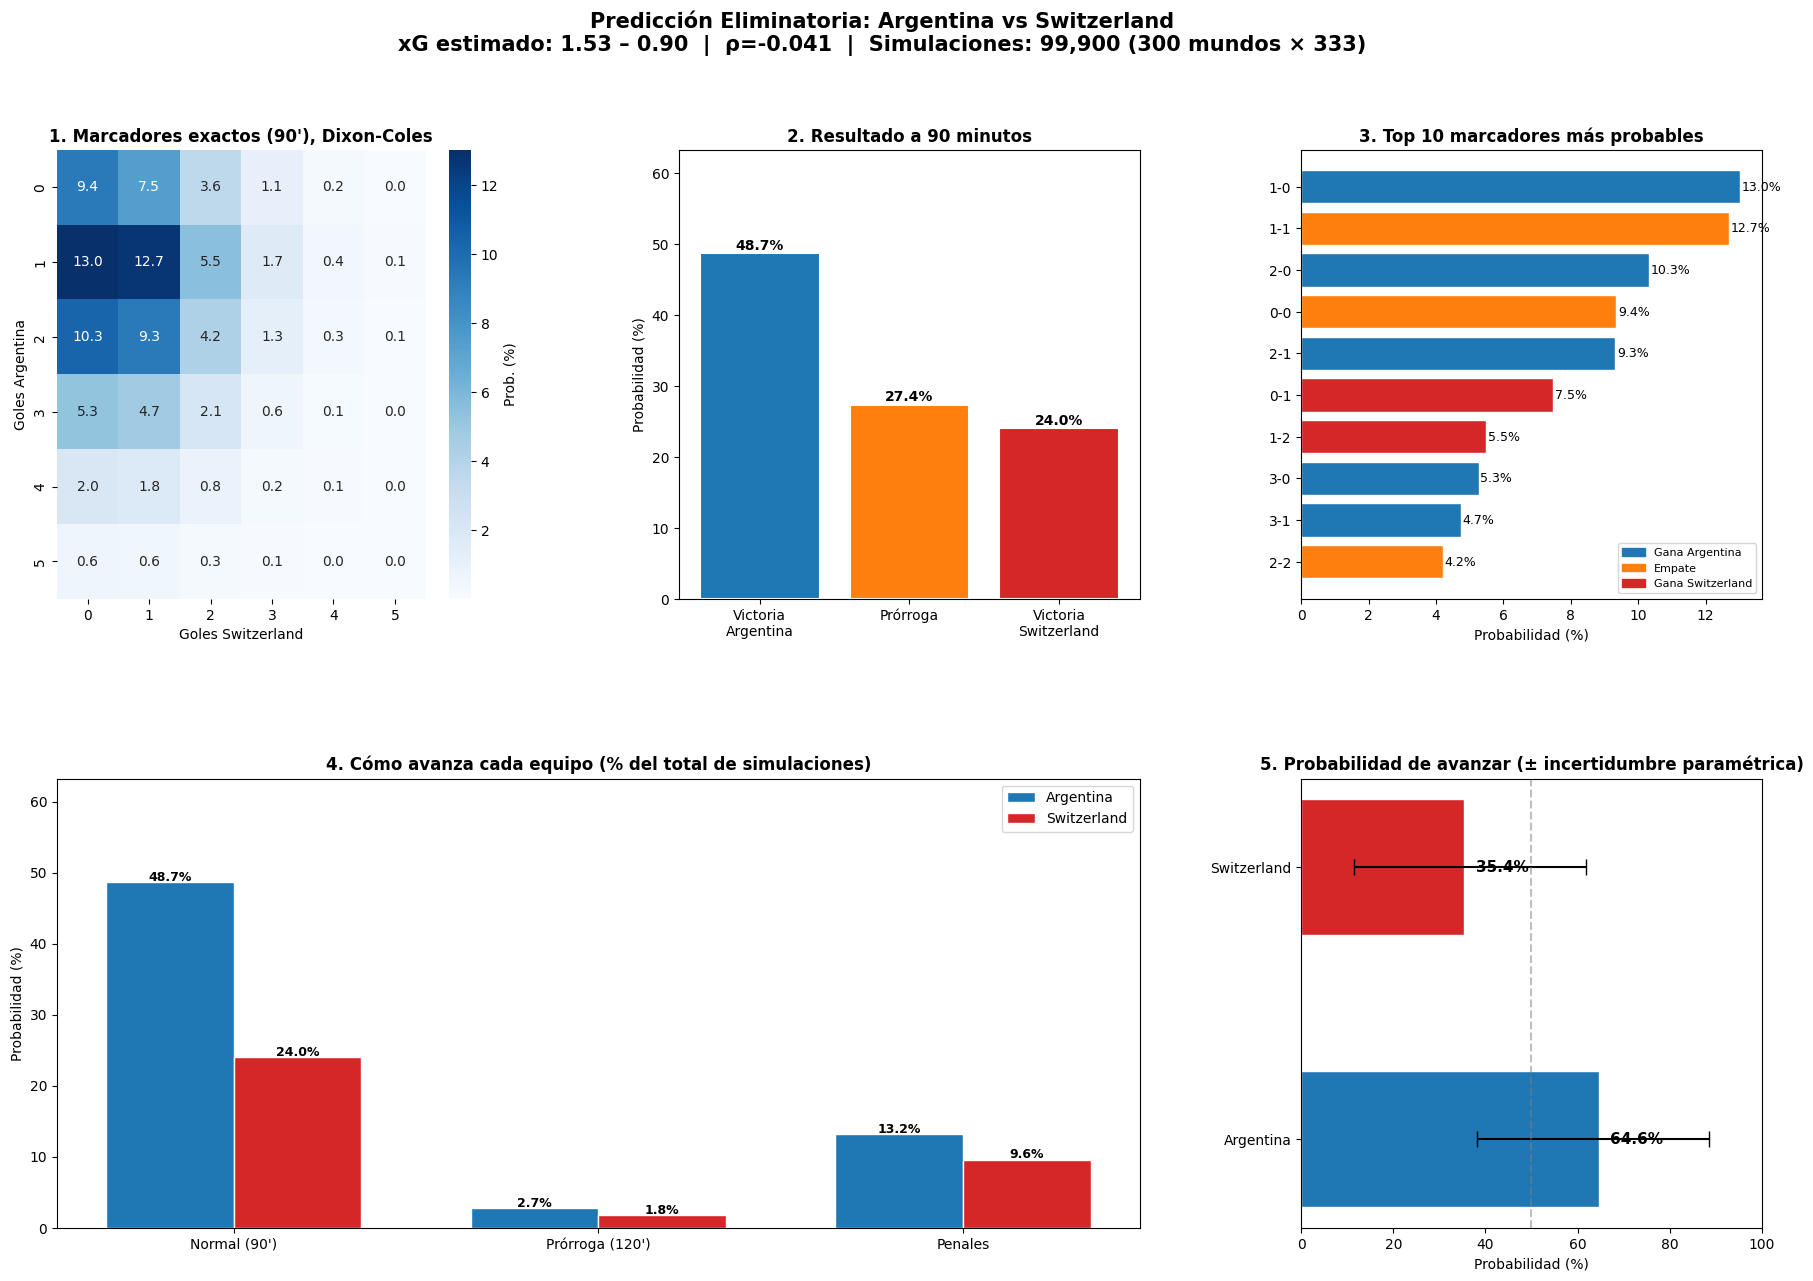


✅ Gráfico guardado como 'prediccion_eliminatoria.png'

💡 Para cambiar el cruce, modifica 'equipo_1' y 'equipo_2' al inicio de la Celda 2.


In [ ]:

# ==========================================================
# CELDA 6: OUTPUT ESTRUCTURADO Y VISUALIZACIÓN
# ==========================================================

print("\n" + "═" * 65)
print(f"  🏆  PREDICCIÓN ELIMINATORIA:  {equipo_1}  vs  {equipo_2}")
print("═" * 65)
print(f"\n  xG estimado: {equipo_1} {xg1:.2f} – {xg2:.2f} {equipo_2}   (ρ Dixon-Coles = {rho_hat:+.3f})")
print(f"\n  ─── RESULTADO A 90 MINUTOS ────────────────────────────────")
print(f"  Victoria {equipo_1:20s}: {prob_e1_normal:.1%}")
print(f"  Prórroga (empate a 90'):    : {prob_prorroga:.1%}")
print(f"  Victoria {equipo_2:20s}: {prob_e2_normal:.1%}")
print(f"\n  ─── SI VA A PRÓRROGA (30' extra) ──────────────────────────")
print(f"  {equipo_1} gana en prórroga  : {prob_e1_prorroga:.1%}  de todos los partidos")
print(f"  {equipo_2} gana en prórroga  : {prob_e2_prorroga:.1%}  de todos los partidos")
print(f"  Van a penales               : {prob_llegan_pen:.1%}  de todos los partidos")
print(f"\n  ─── SI VA A PENALES ────────────────────────────────────────")
print(f"  {equipo_1} gana la tanda     : {p1_gana_penales:.1%}  (condicional, estimación puntual)")
print(f"  {equipo_2} gana la tanda     : {p2_gana_penales:.1%}  (condicional, estimación puntual)")
print(f"  {equipo_1} gana penales      : {prob_e1_penales:.1%}  de todos los partidos")
print(f"  {equipo_2} gana penales      : {prob_e2_penales:.1%}  de todos los partidos")
print(f"\n  ═══ PROBABILIDAD DE AVANZAR ════════════════════════════════")
print(f"  {equipo_1:25s}: {prob_avanza_e1:.1%}   (rango 90% por incertidumbre paramétrica: {ci_e1_5:.1%}-{ci_e1_95:.1%})")
print(f"  {equipo_2:25s}: {prob_avanza_e2:.1%}   (rango 90% por incertidumbre paramétrica: {ci_e2_5:.1%}-{ci_e2_95:.1%})")
print(f"\n  🎯  PRONÓSTICO:  {favorito} avanza ({prob_fav:.1%})")
if fav_normal > fav_prorroga and fav_normal > fav_penales:
    print(f"      → Más probable que sea en los 90 minutos ({fav_normal:.1%})")
elif fav_prorroga > fav_penales:
    print(f"      → Más probable que sea en prórroga ({fav_prorroga:.1%})")
else:
    print(f"      → Partido muy igualado, posibles penales ({fav_penales:.1%})")
print("═" * 65)

print(f"\nTop 10 marcadores más probables a 90' (con corrección Dixon-Coles):")
for m, p in top_10_marcadores:
    bar = "█" * int(p * 200)
    print(f"  {m:6s}  {p:.1%}  {bar}")

# ----------------------------------------------------------
# VISUALIZACIÓN
# ----------------------------------------------------------
fig = plt.figure(figsize=(22, 14))
fig.suptitle(
    f"Predicción Eliminatoria: {equipo_1} vs {equipo_2}\n"
    f"xG estimado: {xg1:.2f} – {xg2:.2f}  |  ρ={rho_hat:+.3f}  |  Simulaciones: {N_SIMULACIONES:,} ({N_BOOTSTRAP} mundos × {inner_n:,})",
    fontsize=15, fontweight='bold', y=0.98
)

gs_layout = fig.add_gridspec(2, 3, hspace=0.40, wspace=0.35)

# ── Panel 1: Heatmap marcadores (90') ──
ax1 = fig.add_subplot(gs_layout[0, 0])
sns.heatmap(
    matriz_probabilidad * 100,
    annot=True, fmt=".1f", cmap="Blues",
    cbar_kws={'label': 'Prob. (%)'},
    xticklabels=range(MAX_GOLES + 1),
    yticklabels=range(MAX_GOLES + 1),
    ax=ax1
)
ax1.set_title("1. Marcadores exactos (90'), Dixon-Coles", fontweight='bold')
ax1.set_xlabel(f"Goles {equipo_2}")
ax1.set_ylabel(f"Goles {equipo_1}")

# ── Panel 2: Probabilidades 90' (victoria / prórroga) ──
ax2 = fig.add_subplot(gs_layout[0, 1])
cats_90 = [f"Victoria\n{equipo_1}", "Prórroga", f"Victoria\n{equipo_2}"]
vals_90 = [prob_e1_normal * 100, prob_prorroga * 100, prob_e2_normal * 100]
cols_90 = ["#1f77b4", "#ff7f0e", "#d62728"]
bars = ax2.bar(cats_90, vals_90, color=cols_90, edgecolor='white', linewidth=1.5)
ax2.set_title("2. Resultado a 90 minutos", fontweight='bold')
ax2.set_ylabel("Probabilidad (%)")
ax2.set_ylim(0, max(vals_90) * 1.3)
for bar, val in zip(bars, vals_90):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
             f"{val:.1f}%", ha='center', fontweight='bold', fontsize=10)

# ── Panel 3: Top 10 marcadores ──
ax3 = fig.add_subplot(gs_layout[0, 2])
etiquetas = [m[0] for m in top_10_marcadores][::-1]
valores   = [m[1] * 100 for m in top_10_marcadores][::-1]
colores_m = []
for m in etiquetas:
    a, b = map(int, m.split('-'))
    if a > b:
        colores_m.append("#1f77b4")
    elif a < b:
        colores_m.append("#d62728")
    else:
        colores_m.append("#ff7f0e")
ax3.barh(etiquetas, valores, color=colores_m, edgecolor='white')
ax3.set_title("3. Top 10 marcadores más probables", fontweight='bold')
ax3.set_xlabel("Probabilidad (%)")
for idx, val in enumerate(valores):
    ax3.text(val + 0.05, idx, f"{val:.1f}%", va='center', fontsize=9)
legend_patches = [
    mpatches.Patch(color="#1f77b4", label=f"Gana {equipo_1}"),
    mpatches.Patch(color="#ff7f0e", label="Empate"),
    mpatches.Patch(color="#d62728", label=f"Gana {equipo_2}"),
]
ax3.legend(handles=legend_patches, loc='lower right', fontsize=8)

# ── Panel 4: Desglose de cómo avanza cada equipo ──
ax4 = fig.add_subplot(gs_layout[1, 0:2])
categorias = ['Normal (90\')', 'Prórroga (120\')', 'Penales']
vals_e1 = [prob_e1_normal * 100, prob_e1_prorroga * 100, prob_e1_penales * 100]
vals_e2 = [prob_e2_normal * 100, prob_e2_prorroga * 100, prob_e2_penales * 100]

x = np.arange(len(categorias))
width = 0.35
b1 = ax4.bar(x - width/2, vals_e1, width, label=equipo_1, color="#1f77b4", edgecolor='white')
b2 = ax4.bar(x + width/2, vals_e2, width, label=equipo_2, color="#d62728", edgecolor='white')
ax4.set_title("4. Cómo avanza cada equipo (% del total de simulaciones)", fontweight='bold')
ax4.set_ylabel("Probabilidad (%)")
ax4.set_xticks(x)
ax4.set_xticklabels(categorias)
ax4.legend()
ax4.set_ylim(0, max(max(vals_e1), max(vals_e2)) * 1.3)
for bar, val in zip(list(b1) + list(b2), vals_e1 + vals_e2):
    if val > 0.2:
        ax4.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
                 f"{val:.1f}%", ha='center', fontsize=9, fontweight='bold')

# ── Panel 5: Probabilidad de avanzar (con banda de incertidumbre paramétrica) ──
ax5 = fig.add_subplot(gs_layout[1, 2])
equipos_label = [equipo_1, equipo_2]
probs_avanzar = [prob_avanza_e1 * 100, prob_avanza_e2 * 100]
colores_av    = ["#1f77b4", "#d62728"]
b_av = ax5.barh(equipos_label, probs_avanzar, color=colores_av, edgecolor='white', height=0.5)
ax5.set_title("5. Probabilidad de avanzar (± incertidumbre paramétrica)", fontweight='bold')
ax5.set_xlabel("Probabilidad (%)")
ax5.set_xlim(0, 100)

err_low  = [max((prob_avanza_e1 - ci_e1_5) * 100, 0), max((prob_avanza_e2 - ci_e2_5) * 100, 0)]
err_high = [max((ci_e1_95 - prob_avanza_e1) * 100, 0), max((ci_e2_95 - prob_avanza_e2) * 100, 0)]
ax5.errorbar(probs_avanzar, equipos_label, xerr=[err_low, err_high],
             fmt='none', ecolor='black', elinewidth=1.5, capsize=6)

for bar, val in zip(b_av, probs_avanzar):
    ax5.text(val + 2.5, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va='center', fontweight='bold', fontsize=11)

ax5.axvline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

plt.savefig("prediccion_eliminatoria.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico guardado como 'prediccion_eliminatoria.png'")
print("\n💡 Para cambiar el cruce, modifica 'equipo_1' y 'equipo_2' al inicio de la Celda 2.")